# Análise Não Supervisionada e Exploração Semântica de Notícias
**Residência em IA - PUC-Campinas / Instituto de Pesquisas Eldorado**
**Projeto Stroj**

Este notebook utiliza técnicas de **aprendizado não supervisionado** sobre representações vetoriais (*embeddings*) de textos armazenados em formato comprimido `.npz`.

> **Objetivo:** O foco deste estudo **não é a classificação** (ex: prever se a notícia é falsa ou verdadeira), mas sim **analisar o comportamento, a distribuição topológica e os agrupamentos temáticos naturais** do conjunto de notícias, além de disponibilizar um **mecanismo de busca semântica por vizinhança** para encontrar as notícias mais próximas de qualquer notícia escolhida.

---

### Módulos Principais do Notebook:
1. **Carregamento e Alinhamento:** Leitura dos embeddings (`.npz`) e sincronização com os textos originais (`dataset.csv`), aplicando normalização L2 (equivalência entre distância euclidiana e similaridade de cosseno).
2. **Análise de Variância e Dimensionalidade:** Estudo da dispersão vetorial via PCA (*Scree Plot*).
3. **Exploração do Número Natural de Agrupamentos ($k$):** Avaliação de granularidade semântica para $k \in [2, 15]$ através do Método do Cotovelo (*Inércia*) e *Silhouette Score*.
4. **Benchmarking de Algoritmos de Agrupamento:**
   - **Partição:** K-Means e MiniBatch K-Means
   - **Probabilístico:** Gaussian Mixture Models (GMM)
   - **Hierárquico:** Agglomerative Clustering (com visualização de Dendrograma)
   - **Baseados em Densidade:** DBSCAN (com k-distância) e HDBSCAN
   - **Baseado em Árvore:** BIRCH
5. **Comportamento e Distribuição dos Clusters (Cluster Profiling):**
   - Distribuição de tamanho e densidade de cada cluster.
   - **Identificação da Notícia Exemplar (Medoid):** Extração do texto central de cada cluster para interpretação temática.
6. **Sistema de Busca Semântica (Notícias Mais Próximas):**
   - Consulta interativa por índice da notícia: encontra as notícias semanticamente mais próximas com métrica de similaridade de cosseno ($0\%$ a $100\%$).
   - Projeção gráfica 2D destacando a notícia escolhida e seus vizinhos imediatos.
7. **Detecção de Anomalias:** Identificação de notícias atípicas ou isoladas via Isolation Forest e LOF.
8. **Consolidação e Exportação:** Métricas comparativas, gráficos e exportação em `.csv` e `.npz`.


### 1. Importação de Bibliotecas e Configuração do Ambiente
___
**O que esta célula faz:**
Carrega bibliotecas de manipulação de dados, computação numérica, visualização e algoritmos de aprendizado não supervisionado do `scikit-learn` e `scipy`.


In [68]:
import os
import time
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    DBSCAN,
    HDBSCAN,
    Birch
)
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    v_measure_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

# Configurações de estilo e visualização
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


### 2. Configurações de Caminhos e Hiperparâmetros
___
**O que esta célula faz:**
Define os caminhos dos arquivos `.npz` e do `.csv` com os textos das notícias, além de parâmetros de exploração de clusters e controle de amostragem.

**Parâmetros configuráveis:**
* `DATA_EMBEDDINGS_PATH`: Caminho do arquivo `.npz` com os vetores.
* `DATA_CSV_PATH`: Caminho do arquivo `.csv` contendo o texto das notícias (para busca semântica e inspeção textual).
* `TARGET_K`: Quantidade de grupos semânticos/temas a serem investigados nos algoritmos de partição (não é classificação; escolha um valor como 5, 6, 8 para analisar múltiplos tópicos).
* `K_RANGE`: Intervalo de $k$ a testar na análise do cotovelo e silhueta ($2$ até $15$).
* `SAMPLE_SIZE_EVAL`: Limite de amostras para cálculos $O(N^2)$ (silhueta/t-SNE) garantindo execução ágil em bases com dezenas de milhares de amostras.


In [69]:
# Caminhos de arquivos (.npz e .csv)
DATA_EMBEDDINGS_PATH = 'data_bert_train_16_09.npz'
possible_npz_paths = [
    'data_bert_train_16_09.npz',
    os.path.join('model', 'data_bert_train_16_09.npz'),
    os.path.join('..', 'model', 'data_bert_train_16_09.npz'),
    'data_bert.npz',
    os.path.join('model', 'data_bert.npz'),
    os.path.join('..', 'model', 'data_bert.npz')
]
for p in possible_npz_paths:
    if os.path.exists(p):
        DATA_EMBEDDINGS_PATH = p
        break

DATA_CSV_PATH = '../training_data/dataset.csv'
possible_csv_paths = [
    '../training_data/dataset.csv',
    'training_data/dataset.csv',
    os.path.join('..', 'training_data', 'dataset.csv'),
    os.path.join('training_data', 'dataset.csv'),
    'dataset.csv'
]
for p in possible_csv_paths:
    if os.path.exists(p):
        DATA_CSV_PATH = p
        break

OUTPUT_DIR = 'results_unsupervised'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hiperparâmetros de exploração temática
RANDOM_STATE = 42
TARGET_K = 4           # Número de temas/tópicos latentes para particionamento inicial (ajustável)
K_RANGE = range(2, 16) # Intervalo para análise de cotovelo e silhueta
SAMPLE_SIZE_EVAL = 5000
APPLY_PCA_PRE_CLUSTERING = True
PCA_DIMS = 50

print(f"Arquivo NPZ: {DATA_EMBEDDINGS_PATH}")
print(f"Arquivo CSV: {DATA_CSV_PATH}")
print(f"Diretório de saída: {OUTPUT_DIR}")
print(f"TARGET_K inicial: {TARGET_K} | Intervalo de K: [{min(K_RANGE)}, {max(K_RANGE)}]")


Arquivo NPZ: data_bert_train_16_09.npz
Arquivo CSV: ../training_data/dataset.csv
Diretório de saída: results_unsupervised
TARGET_K inicial: 4 | Intervalo de K: [2, 15]


### 3. Carregamento dos Embeddings e Associação com os Textos das Notícias
___
**O que esta célula faz:**
1. **Leitura dos Vetores (.npz):** Carrega a matriz de embeddings $X$ e rótulos de referência opcionais $y$.
2. **Associação com os Textos (.csv):** Carrega o texto original das notícias do CSV (garantindo correspondência com a divisão estratificada utilizada na geração dos embeddings).
3. **Normalização L2:** Normaliza cada vetor para ter norma unitária ($\|x\|_2 = 1$). Com isso:
$$\|u - v\|^2 = 2 - 2 \cos(u, v)$$
A distância euclidiana torna-se uma transformação direta da similaridade de cosseno, otimizando algoritmos baseados em distância para vetores de linguagem.


In [70]:
from sklearn.model_selection import train_test_split

# 1. Carregamento dos embeddings (.npz)
if os.path.exists(DATA_EMBEDDINGS_PATH):
    print(f"Carregando embeddings de '{DATA_EMBEDDINGS_PATH}'...")
    npz_data = np.load(DATA_EMBEDDINGS_PATH, allow_pickle=True)
    print(f"Chaves disponíveis no .npz: {list(npz_data.files)}")

    emb_key = next((k for k in ['embeddings', 'X', 'features'] if k in npz_data.files), None)
    lbl_key = next((k for k in ['labels', 'y', 'label'] if k in npz_data.files), None)

    X_raw = npz_data[emb_key].astype(np.float32)
    y_true = npz_data[lbl_key] if lbl_key is not None else None
    print(f"Embeddings carregados: {X_raw.shape}")
else:
    print(f"Arquivo '{DATA_EMBEDDINGS_PATH}' não encontrado. Gerando dados sintéticos demonstrativos...")
    from sklearn.datasets import make_blobs
    X_raw, y_true = make_blobs(n_samples=2500, n_features=768, centers=TARGET_K, cluster_std=3.0, random_state=RANDOM_STATE)
    X_raw = X_raw.astype(np.float32)

# 2. Carregamento e alinhamento dos textos das notícias
news_texts = []
if os.path.exists(DATA_CSV_PATH):
    print(f"Carregando textos de '{DATA_CSV_PATH}'...")
    df_full = pd.read_csv(DATA_CSV_PATH)
    if 'text' in df_full.columns:
        if len(df_full) == len(X_raw):
            news_texts = df_full['text'].astype(str).tolist()
        elif len(df_full) > len(X_raw) and y_true is not None:
            # Sincronização com o train_test_split estratificado utilizado na criação do .npz
            df_train, _ = train_test_split(df_full, train_size=len(X_raw), random_state=42, stratify=df_full['label'])
            news_texts = df_train['text'].astype(str).tolist()
        else:
            news_texts = df_full['text'].iloc[:len(X_raw)].astype(str).tolist()
        print(f"Textos das notícias vinculados com sucesso: {len(news_texts)} notícias.")
else:
    print("CSV de textos não encontrado. Criando referências de texto sintéticas...")
    news_texts = [f"Notícia #{i} - Texto sintético sobre o tópico {y_true[i] if y_true is not None else ''}" for i in range(len(X_raw))]

# Verificação numérica
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=1e6, neginf=-1e6)

# Normalização L2 unitária
X = normalize(X_raw, norm='l2')
print(f"Matriz de embeddings processada X: {X.shape} | Norma média: {np.linalg.norm(X, axis=1).mean():.4f}")


Carregando embeddings de 'data_bert_train_16_09.npz'...
Chaves disponíveis no .npz: ['embeddings', 'labels']
Embeddings carregados: (39219, 772)
Carregando textos de '../training_data/dataset.csv'...
Textos das notícias vinculados com sucesso: 39219 notícias.
Matriz de embeddings processada X: (39219, 772) | Norma média: 1.0000


### 4. Análise de Variância e Estrutura Dimensional (PCA)
___
**O que esta célula faz:**
Examina a distribuição de variância ao longo dos componentes principais. Avalia se os embeddings concentram a informação semântica em um subespaço de menor dimensão, reduzindo o ruído para as etapas subsequentes.


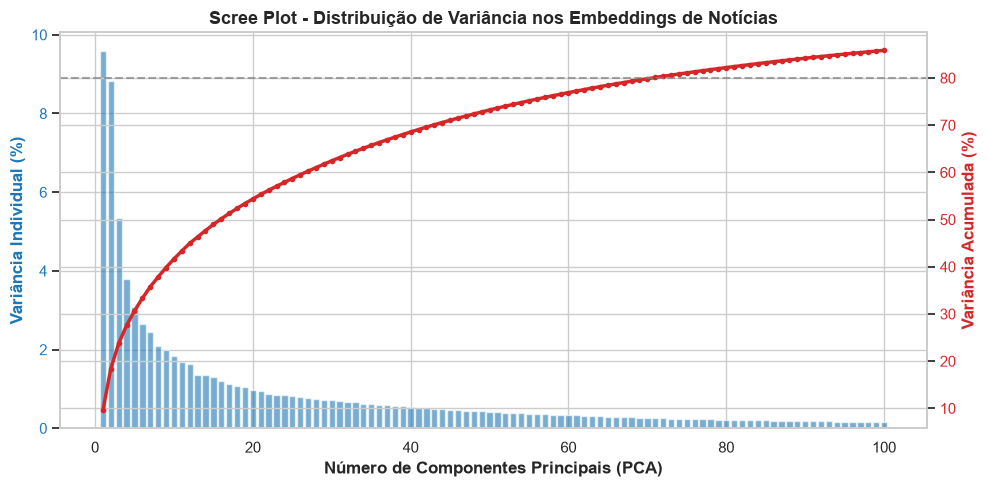

Dimensão reduzida X_pca: (39219, 50) (Variância preservada: 73.22%)


In [71]:
n_comp = min(100, X.shape[1], X.shape[0] - 1)
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
pca.fit(X)

cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Número de Componentes Principais (PCA)', fontweight='bold')
ax1.set_ylabel('Variância Individual (%)', color=color, fontweight='bold')
ax1.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_ * 100, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Variância Acumulada (%)', color=color, fontweight='bold')
ax2.plot(range(1, len(cum_var) + 1), cum_var, color=color, linewidth=2.5, marker='o', markersize=3)
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.7, label='80% de Variância')

plt.title('Scree Plot - Distribuição de Variância nos Embeddings de Notícias', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# Projeção intermediária para aceleração dos algoritmos de vizinhança e densidade
pca_red = PCA(n_components=min(PCA_DIMS, X.shape[1]), random_state=RANDOM_STATE)
X_pca = pca_red.fit_transform(X)
print(f"Dimensão reduzida X_pca: {X_pca.shape} (Variância preservada: {pca_red.explained_variance_ratio_.sum()*100:.2f}%)")


### 5. Exploração do Número de Grupos Temáticos ($k \in [2, 15]$)
___
**O que esta célula faz:**
Como o objetivo é analisar a estrutura temática natural das notícias (e não forçar 2 classes), testamos uma faixa ampla de $k \in [2, 15]$:
* **Método do Cotovelo (*Inércia / WCSS*):** Mede a compacidade dos grupos.
* **Silhouette Score:** Mede a separação e nitidez entre clusters (valores mais altos indicam grupos mais coesos e distintos).
* **Davies-Bouldin:** Avalia a similaridade entre clusters (valores menores indicam agrupamentos melhores).


Calculando métricas para k de 2 a 15 usando 5000 amostras...
k =  2 | Inércia:    2170.73 | Silhueta: 0.0636 | Davies-Bouldin: 3.7767
k =  3 | Inércia:    2021.88 | Silhueta: 0.0919 | Davies-Bouldin: 2.5690
k =  4 | Inércia:    1912.74 | Silhueta: 0.0862 | Davies-Bouldin: 2.9691
k =  5 | Inércia:    1870.93 | Silhueta: 0.0746 | Davies-Bouldin: 3.0542
k =  6 | Inércia:    1833.72 | Silhueta: 0.0733 | Davies-Bouldin: 2.9845
k =  7 | Inércia:    1795.61 | Silhueta: 0.0769 | Davies-Bouldin: 2.8122
k =  8 | Inércia:    1783.34 | Silhueta: 0.0717 | Davies-Bouldin: 3.3182
k =  9 | Inércia:    1751.59 | Silhueta: 0.0675 | Davies-Bouldin: 3.3413
k = 10 | Inércia:    1714.61 | Silhueta: 0.0725 | Davies-Bouldin: 3.0868
k = 11 | Inércia:    1711.78 | Silhueta: 0.0672 | Davies-Bouldin: 3.3695
k = 12 | Inércia:    1677.73 | Silhueta: 0.0718 | Davies-Bouldin: 3.2796
k = 13 | Inércia:    1651.24 | Silhueta: 0.0763 | Davies-Bouldin: 3.2824
k = 14 | Inércia:    1633.92 | Silhueta: 0.0763 | Davies-Bouldi

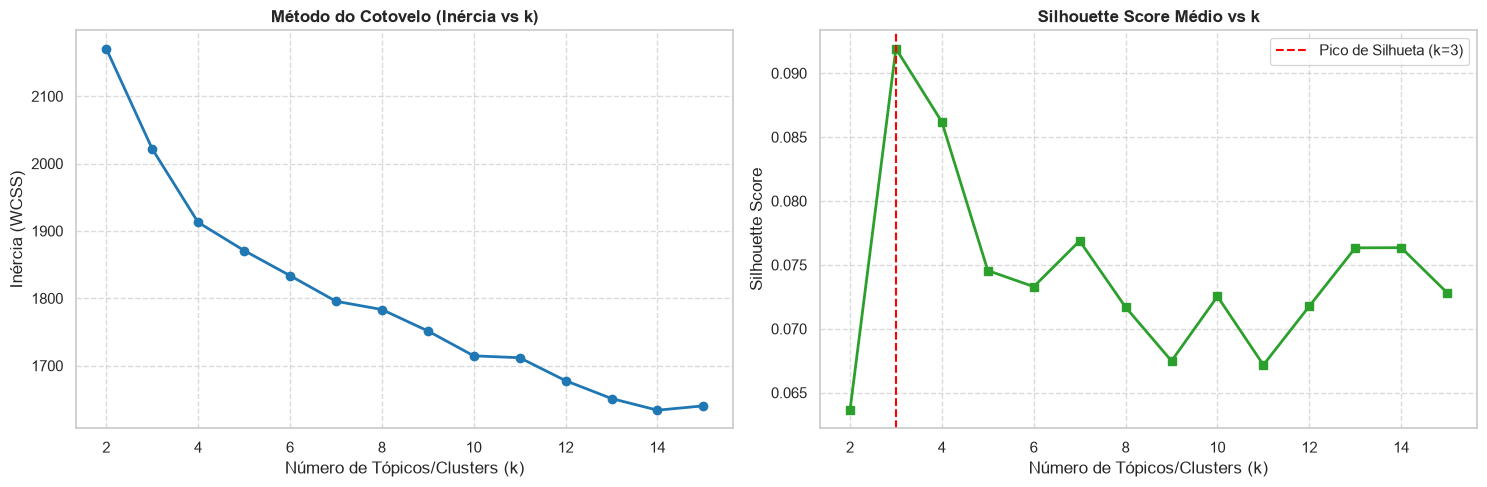

Sugestão com maior pontuação de Silhueta: k = 3


In [72]:
inertias = []
sil_scores = []
db_scores = []

if len(X) > SAMPLE_SIZE_EVAL:
    np.random.seed(RANDOM_STATE)
    idx_eval = np.random.choice(len(X), SAMPLE_SIZE_EVAL, replace=False)
    X_k_eval = X[idx_eval]
else:
    X_k_eval = X

print(f"Calculando métricas para k de {min(K_RANGE)} a {max(K_RANGE)} usando {len(X_k_eval)} amostras...")

for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=1024, n_init=3)
    lbls = km.fit_predict(X_k_eval)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_k_eval, lbls))
    db_scores.append(davies_bouldin_score(X_k_eval, lbls))
    print(f"k = {k:2d} | Inércia: {km.inertia_:10.2f} | Silhueta: {sil_scores[-1]:.4f} | Davies-Bouldin: {db_scores[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Inércia (Cotovelo)
ax1.plot(list(K_RANGE), inertias, marker='o', color='tab:blue', linewidth=2)
ax1.set_title('Método do Cotovelo (Inércia vs k)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de Tópicos/Clusters (k)')
ax1.set_ylabel('Inércia (WCSS)')
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Silhouette Score
ax2.plot(list(K_RANGE), sil_scores, marker='s', color='tab:green', linewidth=2)
best_k = list(K_RANGE)[np.argmax(sil_scores)]
ax2.axvline(x=best_k, color='red', linestyle='--', label=f'Pico de Silhueta (k={best_k})')
ax2.set_title('Silhouette Score Médio vs k', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Tópicos/Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Sugestão com maior pontuação de Silhueta: k = {best_k}")
# Caso deseje adotar o valor sugerido pelo pico de silhueta, descomente:
# TARGET_K = best_k


### 6. Pipeline Unificado de Avaliação dos Agrupamentos
___
**O que esta célula faz:**
Padroniza o registro de métricas de qualidade intrínseca de cada algoritmo testado:
* **Silhouette Score:** Coesão intra-cluster vs. separação inter-cluster.
* **Davies-Bouldin:** Similaridade mútua entre clusters.
* **Calinski-Harabasz:** Razão de dispersão entre/dentro dos clusters.
* **Taxa de Ruído (%):** Percentual de notícias isoladas (rótulo `-1` em DBSCAN/HDBSCAN).


In [73]:
unsupervised_results = []
predicted_cluster_labels = {}

def evaluate_unsupervised_model(model_name, labels, X_features, y_ref=None, fit_time_sec=0.0):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels != -1])
    n_noise = int(np.sum(labels == -1))
    noise_ratio = float(n_noise / len(labels)) * 100

    valid_mask = labels != -1 if n_noise > 0 else np.ones(len(labels), dtype=bool)
    n_valid = np.sum(valid_mask)

    sil, db, ch = np.nan, np.nan, np.nan

    if n_clusters >= 2 and n_valid > n_clusters:
        X_eval = X_features[valid_mask]
        lbl_eval = labels[valid_mask]

        sample_lim = min(SAMPLE_SIZE_EVAL, len(X_eval))
        if len(X_eval) > sample_lim:
            idx = np.random.choice(len(X_eval), sample_lim, replace=False)
            sil = float(silhouette_score(X_eval[idx], lbl_eval[idx]))
        else:
            sil = float(silhouette_score(X_eval, lbl_eval))

        db = float(davies_bouldin_score(X_eval, lbl_eval))
        ch = float(calinski_harabasz_score(X_eval, lbl_eval))

    ari, nmi, v_meas = np.nan, np.nan, np.nan
    if y_ref is not None and n_clusters >= 2:
        y_valid = y_ref[valid_mask]
        lbl_eval = labels[valid_mask]
        ari = float(adjusted_rand_score(y_valid, lbl_eval))
        nmi = float(normalized_mutual_info_score(y_valid, lbl_eval))
        v_meas = float(v_measure_score(y_valid, lbl_eval))

    res = {
        'Model': model_name,
        'N_Clusters': n_clusters,
        'Noise_Count': n_noise,
        'Noise_Ratio_%': round(noise_ratio, 2),
        'Silhouette': round(sil, 4) if not np.isnan(sil) else None,
        'Davies_Bouldin': round(db, 4) if not np.isnan(db) else None,
        'Calinski_Harabasz': round(ch, 2) if not np.isnan(ch) else None,
        'ARI_Ref': round(ari, 4) if not np.isnan(ari) else None,
        'Fit_Time_Sec': round(fit_time_sec, 3)
    }

    unsupervised_results.append(res)
    predicted_cluster_labels[model_name] = labels

    print(f"[{model_name}] Clusters formados: {n_clusters} | Ruído: {noise_ratio:.1f}% | Tempo: {fit_time_sec:.2f}s")
    print(f"   -> Silhueta: {res['Silhouette']} | Davies-Bouldin: {res['Davies_Bouldin']} | Calinski-Harabasz: {res['Calinski_Harabasz']}")
    print("-" * 65)
    return res

print("Pipeline de avaliação inicializado.")


Pipeline de avaliação inicializado.


### 7. Algoritmos de Partição e Probabilísticos (K-Means, MiniBatchKMeans, GMM)
___
**O que esta célula faz:**
Aplica três dos principais algoritmos de partição vetorial:
1. **K-Means:** Agrupamento por centróides iterativos via distância euclidiana nos embeddings normalizados.
2. **MiniBatch K-Means:** Versão com mini-lotes estocásticos, altamente veloz em bases volumosas.
3. **Gaussian Mixture Model (GMM):** Agrupamento probabilístico que modela a distribuição dos dados como uma mistura de gaussianas multidimensionais.


In [74]:
# 1. K-Means
t0 = time.time()
kmeans = KMeans(n_clusters=TARGET_K, init='k-means++', n_init=10, random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X)
evaluate_unsupervised_model('K-Means', labels_kmeans, X, y_true, fit_time_sec=time.time() - t0)

# 2. MiniBatch K-Means
t0 = time.time()
mb_kmeans = MiniBatchKMeans(n_clusters=TARGET_K, batch_size=1024, n_init=5, random_state=RANDOM_STATE)
labels_mb_kmeans = mb_kmeans.fit_predict(X)
evaluate_unsupervised_model('MiniBatch K-Means', labels_mb_kmeans, X, y_true, fit_time_sec=time.time() - t0)

# 3. Gaussian Mixture Model (GMM)
t0 = time.time()
gmm_feats = X_pca if APPLY_PCA_PRE_CLUSTERING else X
gmm = GaussianMixture(n_components=TARGET_K, covariance_type='diag', random_state=RANDOM_STATE)
labels_gmm = gmm.fit_predict(gmm_feats)
evaluate_unsupervised_model('Gaussian Mixture (GMM)', labels_gmm, X, y_true, fit_time_sec=time.time() - t0)


[K-Means] Clusters formados: 4 | Ruído: 0.0% | Tempo: 6.31s
   -> Silhueta: 0.085 | Davies-Bouldin: 2.9831 | Calinski-Harabasz: 2794.14
-----------------------------------------------------------------
[MiniBatch K-Means] Clusters formados: 4 | Ruído: 0.0% | Tempo: 0.99s
   -> Silhueta: 0.0856 | Davies-Bouldin: 2.9856 | Calinski-Harabasz: 2791.9
-----------------------------------------------------------------
[Gaussian Mixture (GMM)] Clusters formados: 4 | Ruído: 0.0% | Tempo: 0.99s
   -> Silhueta: 0.0436 | Davies-Bouldin: 3.023 | Calinski-Harabasz: 1688.58
-----------------------------------------------------------------


{'Model': 'Gaussian Mixture (GMM)',
 'N_Clusters': 4,
 'Noise_Count': 0,
 'Noise_Ratio_%': 0.0,
 'Silhouette': 0.0436,
 'Davies_Bouldin': 3.023,
 'Calinski_Harabasz': 1688.58,
 'ARI_Ref': 0.2407,
 'Fit_Time_Sec': 0.989}

### 8. Agrupamento Hierárquico Aglomerativo e Dendrograma
___
**O que esta célula faz:**
1. Gera um **Dendrograma Truncado** para uma amostra representativa de notícias, ilustrando a hierarquia de fusão dos temas.
2. Executa o **Agglomerative Clustering** com critério de ligação *Ward* (minimiza o aumento da variância total a cada fusão).


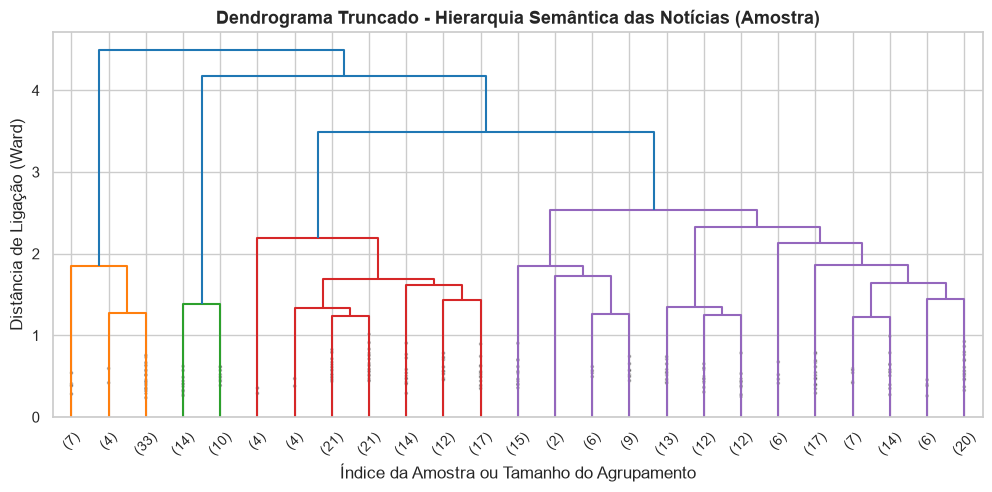

[Agglomerative (Ward)] Clusters formados: 4 | Ruído: 0.0% | Tempo: 0.96s
   -> Silhueta: 0.0738 | Davies-Bouldin: 3.1867 | Calinski-Harabasz: 2515.03
-----------------------------------------------------------------


{'Model': 'Agglomerative (Ward)',
 'N_Clusters': 4,
 'Noise_Count': 0,
 'Noise_Ratio_%': 0.0,
 'Silhouette': 0.0738,
 'Davies_Bouldin': 3.1867,
 'Calinski_Harabasz': 2515.03,
 'ARI_Ref': 0.228,
 'Fit_Time_Sec': 0.964}

In [75]:
# Amostragem para construção do dendrograma
dendro_sample_size = min(300, len(X))
np.random.seed(RANDOM_STATE)
idx_dendro = np.random.choice(len(X), dendro_sample_size, replace=False)
X_dendro = X_pca[idx_dendro] if APPLY_PCA_PRE_CLUSTERING else X[idx_dendro]

linked = linkage(X_dendro, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=25,
    leaf_rotation=45.,
    leaf_font_size=10.,
    show_contracted=True
)
plt.title('Dendrograma Truncado - Hierarquia Semântica das Notícias (Amostra)', fontsize=13, fontweight='bold')
plt.xlabel('Índice da Amostra ou Tamanho do Agrupamento')
plt.ylabel('Distância de Ligação (Ward)')
plt.show()

# Agglomerative Clustering (utiliza amostragem representativa se N > 5000 para evitar O(N^2) de memória/tempo)
t0 = time.time()
sample_agg = min(5000, len(X))
if len(X) > sample_agg:
    np.random.seed(RANDOM_STATE)
    idx_agg = np.random.choice(len(X), sample_agg, replace=False)
    agg_feats_sample = X_pca[idx_agg] if APPLY_PCA_PRE_CLUSTERING else X[idx_agg]
    agg = AgglomerativeClustering(n_clusters=TARGET_K, metric='euclidean', linkage='ward')
    labels_agg_sample = agg.fit_predict(agg_feats_sample)

    knn_prop = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(agg_feats_sample)
    _, nearest_idx = knn_prop.kneighbors(X_pca if APPLY_PCA_PRE_CLUSTERING else X)
    labels_agg = labels_agg_sample[nearest_idx.flatten()]
else:
    agg_feats = X_pca if APPLY_PCA_PRE_CLUSTERING else X
    agg = AgglomerativeClustering(n_clusters=TARGET_K, metric='euclidean', linkage='ward')
    labels_agg = agg.fit_predict(agg_feats)

evaluate_unsupervised_model('Agglomerative (Ward)', labels_agg, X, y_true, fit_time_sec=time.time() - t0)


### 9. Agrupamento Baseado em Densidade (DBSCAN & HDBSCAN)
___
**O que esta célula faz:**
1. **Gráfico de k-distância:** Plota a distância ordenada ao $k$-ésimo vizinho para guiar a escolha de $\epsilon$ no DBSCAN.
2. **DBSCAN:** Agrupa notícias localizadas em regiões de densidade contínua e rotula notícias isoladas como ruído (`-1`). Não exige especificar o número de clusters a priori.
3. **HDBSCAN:** Abordagem hierárquica por densidade que descobre clusters com diferentes densidades e formas arbitrárias de maneira automática.


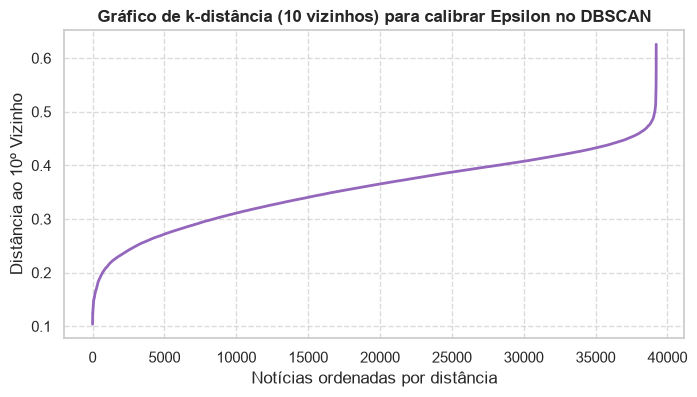

[DBSCAN] Clusters formados: 6 | Ruído: 2.6% | Tempo: 1.80s
   -> Silhueta: 0.0948 | Davies-Bouldin: 1.4917 | Calinski-Harabasz: 293.84
-----------------------------------------------------------------
[HDBSCAN] Clusters formados: 4 | Ruído: 0.0% | Tempo: 3.69s
   -> Silhueta: 0.0963 | Davies-Bouldin: 1.5753 | Calinski-Harabasz: 483.32
-----------------------------------------------------------------


{'Model': 'HDBSCAN',
 'N_Clusters': 4,
 'Noise_Count': 6,
 'Noise_Ratio_%': 0.02,
 'Silhouette': 0.0963,
 'Davies_Bouldin': 1.5753,
 'Calinski_Harabasz': 483.32,
 'ARI_Ref': -0.0132,
 'Fit_Time_Sec': 3.691}

In [76]:
# Gráfico de k-distância
k_neighbors = 10
nbrs = NearestNeighbors(n_neighbors=k_neighbors, metric='euclidean').fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
dist_sorted = np.sort(distances[:, k_neighbors - 1])

plt.figure(figsize=(8, 4))
plt.plot(dist_sorted, color='tab:purple', linewidth=2)
plt.title(f'Gráfico de k-distância ({k_neighbors} vizinhos) para calibrar Epsilon no DBSCAN', fontsize=12, fontweight='bold')
plt.xlabel('Notícias ordenadas por distância')
plt.ylabel(f'Distância ao {k_neighbors}º Vizinho')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 1. DBSCAN
t0 = time.time()
eps_est = float(np.percentile(dist_sorted, 85))
dbscan = DBSCAN(eps=eps_est, min_samples=10, metric='euclidean')
labels_dbscan = dbscan.fit_predict(X_pca)
evaluate_unsupervised_model('DBSCAN', labels_dbscan, X, y_true, fit_time_sec=time.time() - t0)

# 2. HDBSCAN (amostragem representativa se N > 8000 para agilidade no grafo de densidade)
t0 = time.time()
sample_hdb = min(8000, len(X))
if len(X) > sample_hdb:
    np.random.seed(RANDOM_STATE)
    idx_hdb = np.random.choice(len(X), sample_hdb, replace=False)
    hdb_feats_sample = X_pca[idx_hdb] if APPLY_PCA_PRE_CLUSTERING else X[idx_hdb]
    hdb = HDBSCAN(min_cluster_size=25, min_samples=10, metric='euclidean')
    labels_hdb_sample = hdb.fit_predict(hdb_feats_sample)

    knn_prop_hdb = NearestNeighbors(n_neighbors=1, metric='euclidean').fit(hdb_feats_sample)
    _, near_hdb = knn_prop_hdb.kneighbors(X_pca if APPLY_PCA_PRE_CLUSTERING else X)
    labels_hdbscan = labels_hdb_sample[near_hdb.flatten()]
else:
    hdbscan = HDBSCAN(min_cluster_size=25, min_samples=10, metric='euclidean')
    labels_hdbscan = hdbscan.fit_predict(X_pca)

evaluate_unsupervised_model('HDBSCAN', labels_hdbscan, X, y_true, fit_time_sec=time.time() - t0)


### 10. Agrupamento Baseado em Árvore de Recursos (BIRCH)
___
**O que esta célula faz:**
O **BIRCH** constrói uma árvore compacta de subclusters (*Clustering Feature Tree*) em passagem linear pelos dados, sendo ideal para grandes coleções de texto.


In [77]:
t0 = time.time()
birch_feats = X_pca if APPLY_PCA_PRE_CLUSTERING else X
birch = Birch(n_clusters=TARGET_K, threshold=0.3, branching_factor=50)
labels_birch = birch.fit_predict(birch_feats)
evaluate_unsupervised_model('BIRCH', labels_birch, X, y_true, fit_time_sec=time.time() - t0)


[BIRCH] Clusters formados: 4 | Ruído: 0.0% | Tempo: 5.13s
   -> Silhueta: 0.0356 | Davies-Bouldin: 4.0598 | Calinski-Harabasz: 1820.6
-----------------------------------------------------------------


{'Model': 'BIRCH',
 'N_Clusters': 4,
 'Noise_Count': 0,
 'Noise_Ratio_%': 0.0,
 'Silhouette': 0.0356,
 'Davies_Bouldin': 4.0598,
 'Calinski_Harabasz': 1820.6,
 'ARI_Ref': 0.1529,
 'Fit_Time_Sec': 5.127}

### 11. Análise de Comportamento e Distribuição dos Clusters (Cluster Profiling)
___
**O que esta célula faz:**
Para compreender o que cada cluster realmente representa no mundo real:
1. **Distribuição de Tamanhos:** Exibe a quantidade e percentual de notícias alocadas em cada cluster gerado pelo K-Means.
2. **Identificação da Notícia Exemplar (Medoid):** Encontra a notícia mais próxima do centróide de cada cluster (o exemplar representativo do tema central de cada grupo).
3. **Exibição dos Textos Exemplares:** Imprime os trechos das notícias centrais para permitir a interpretação temática de cada grupo.


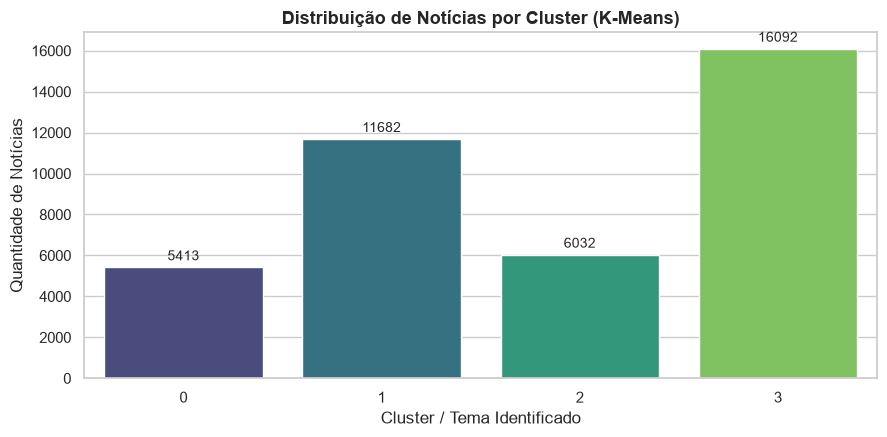

=== NOTÍCIAS EXEMPLARES (CENTRAIS) DE CADA CLUSTER (K-Means) ===

[CLUSTER 0] (5413 notícias - 13.8%)
   -> Notícia Medoid (Índice #7672):
   "Pelo segundo ano consecutivo, o Cruzeiro chega à final da Copa do Brasil sob o comando de Mano Menezes. Muitas vezes criticado por se preocupar muito com a marcação, o treinador foi campeão no ano passado e tem a chance de repetir o feito nesta tempo..."
---------------------------------------------------------------------------

[CLUSTER 1] (11682 notícias - 29.8%)
   -> Notícia Medoid (Índice #12691):
   "Quando Temer foi pra Rússia e Noruega, foi noticiado que a Polícia Federal (PF) tinha encaminhado ao STF seu relatório sobre a investigação pedida pelo procurador-geral quanto à suspeita de que o presidente Temer teria cometido crime de corrupção pas..."
---------------------------------------------------------------------------

[CLUSTER 2] (6032 notícias - 15.4%)
   -> Notícia Medoid (Índice #27785):
   "Mortágua defende novo imposto sobre 

In [78]:
chosen_model_name = 'K-Means'
chosen_labels = predicted_cluster_labels[chosen_model_name]

# 1. Contagem e proporção das notícias por cluster
unique_c, counts_c = np.unique(chosen_labels, return_counts=True)
df_cluster_dist = pd.DataFrame({
    'Cluster': unique_c,
    'Qtd_Noticias': counts_c,
    'Percentual_%': np.round((counts_c / len(chosen_labels)) * 100, 2)
})

plt.figure(figsize=(9, 4.5))
bar_plot = sns.barplot(data=df_cluster_dist[df_cluster_dist['Cluster'] != -1], x='Cluster', y='Qtd_Noticias', palette='viridis')
plt.title(f'Distribuição de Notícias por Cluster ({chosen_model_name})', fontsize=13, fontweight='bold')
plt.xlabel('Cluster / Tema Identificado')
plt.ylabel('Quantidade de Notícias')
for p in bar_plot.patches:
    bar_plot.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

# 2. Localização das notícias exemplares (Medoids centrais de cada cluster)
print(f"=== NOTÍCIAS EXEMPLARES (CENTRAIS) DE CADA CLUSTER ({chosen_model_name}) ===")
cluster_centers = kmeans.cluster_centers_

for c_id in range(TARGET_K):
    c_indices = np.where(chosen_labels == c_id)[0]
    if len(c_indices) == 0:
        continue

    # Distância de todos os pontos do cluster ao centróide
    c_vectors = X[c_indices]
    dists_to_center = np.linalg.norm(c_vectors - cluster_centers[c_id], axis=1)
    closest_idx_in_cluster = np.argmin(dists_to_center)
    medoid_global_idx = c_indices[closest_idx_in_cluster]

    medoid_text = news_texts[medoid_global_idx] if medoid_global_idx < len(news_texts) else "Texto não disponível"
    clean_text = " ".join(medoid_text.strip().split())
    snippet = clean_text[:250] + ("..." if len(clean_text) > 250 else "")

    print(f"\n[CLUSTER {c_id}] ({len(c_indices)} notícias - {len(c_indices)/len(chosen_labels)*100:.1f}%)")
    print(f"   -> Notícia Medoid (Índice #{medoid_global_idx}):")
    print(f"   \"{snippet}\"")
    print("-" * 75)


### 12. Busca Semântica: Encontrar as Notícias Mais Próximas de uma Notícia Escolhida
___
**O que esta célula faz:**
Permite escolher **qualquer notícia do dataset** (através do seu índice) e retornar as **notícias mais semelhantes** com base na similaridade de cosseno calculada nos embeddings.

**Como funciona a métrica:**
Como os vetores estão com normalização L2 unitária, o produto escalar é a similaridade de cosseno:
$$\text{Similaridade}(\mathbf{u}, \mathbf{v}) = \mathbf{u} \cdot \mathbf{v} \in [-1, 1]$$
Uma pontuação próxima de $100\%$ indica conteúdos semanticamente idênticos ou que abordam o mesmo evento factual/narrativa.


In [79]:
# Inicialização do motor de vizinhos mais próximos com distância de cosseno
nn_engine = NearestNeighbors(n_neighbors=15, metric='cosine')
nn_engine.fit(X)

def buscar_noticias_proximas(query_index, top_n=5, max_chars=300):
    if query_index < 0 or query_index >= len(X):
        print(f"Erro: Índice {query_index} fora dos limites do dataset (0 a {len(X)-1}).")
        return None, None

    query_vec = X[query_index].reshape(1, -1)
    distances, neighbor_indices = nn_engine.kneighbors(query_vec, n_neighbors=top_n + 1)

    # O primeiro vizinho é a própria notícia consultada (distância = 0)
    distances = distances[0][1:]
    neighbor_indices = neighbor_indices[0][1:]

    query_text = news_texts[query_index] if query_index < len(news_texts) else "N/A"
    clean_query = " ".join(query_text.strip().split())
    query_cluster = chosen_labels[query_index]

    print("=" * 80)
    print(f"NOTÍCIA CONSULTADA [Índice #{query_index}] | Cluster Atribuído: {query_cluster}")
    print(f"Texto:")
    print(f"\"{clean_query[:max_chars]}...\"")
    print("=" * 80)
    print(f"TOP-{top_n} NOTÍCIAS MAIS PRÓXIMAS (MAIOR SIMILARIDADE SEMÂNTICA):")
    print("-" * 80)

    results = []
    for rank, (idx, dist) in enumerate(zip(neighbor_indices, distances), start=1):
        cos_similarity = (1.0 - dist) * 100.0  # Converte distância cosseno em percentual
        txt = news_texts[idx] if idx < len(news_texts) else "N/A"
        clean_snip = " ".join(txt.strip().split())
        snip = clean_snip[:max_chars] + ("..." if len(clean_snip) > max_chars else "")
        cluster_vizinho = chosen_labels[idx]

        print(f"#{rank} | Índice: {idx:5d} | Similaridade Cosseno: {cos_similarity:6.2f}% | Cluster: {cluster_vizinho}")
        print(f"     \"{snip}\"\n")

        results.append({
            'Rank': rank,
            'Index': idx,
            'Similarity_%': round(cos_similarity, 2),
            'Cosine_Distance': round(dist, 4),
            'Cluster': cluster_vizinho,
            'Snippet': snip
        })

    return pd.DataFrame(results), neighbor_indices

# =========================================================================
# TESTE DA BUSCA: Altere o QUERY_INDEX abaixo para explorar qualquer notícia!
# =========================================================================
QUERY_INDEX = 32  # Escolha qualquer índice entre 0 e len(X)-1
df_neighbors, top_indices = buscar_noticias_proximas(QUERY_INDEX, top_n=5)


NOTÍCIA CONSULTADA [Índice #32] | Cluster Atribuído: 2
Texto:
"“Quando cheguei na presidência, tinham 3,5 milhões de estudantes nas universidades”..."
TOP-5 NOTÍCIAS MAIS PRÓXIMAS (MAIOR SIMILARIDADE SEMÂNTICA):
--------------------------------------------------------------------------------
#1 | Índice:  8290 | Similaridade Cosseno:  95.52% | Cluster: 2
     "“Quando eu saí da presidência, tinham 8,5 milhões de pessoas na universidade”"

#2 | Índice: 29033 | Similaridade Cosseno:  88.51% | Cluster: 2
     "“Eu tô falando de 67 mil estudantes hoje no ensino fundamental [em João Pessoa]”"

#3 | Índice: 20244 | Similaridade Cosseno:  87.79% | Cluster: 2
     "“Até agora foram 2 mil alunos que vieram para a rede pública [da rede privada, durante a pandemia]”"

#4 | Índice: 13317 | Similaridade Cosseno:  85.85% | Cluster: 2
     "“Nós tínhamos mais de 60 mil crianças aguardando vaga em creche quando nós assumimos a gestão”"

#5 | Índice: 30119 | Similaridade Cosseno:  85.53% | Cluster: 2
 

### 13. Visualização da Vizinhança Semântica e Projeções 2D
___
**O que esta célula faz:**
1. Projeta as notícias em um plano bidimensional via **PCA** e **t-SNE**.
2. **Destaque Visual da Consulta:** Destaca a notícia consultada (`QUERY_INDEX`) com uma estrela vermelha ($\bigstar$) e seus vizinhos mais próximos com marcadores especiais, ilustrando a coerência geométrica no espaço latente.
3. Exibe painel com a distribuição global de todos os clusters identificados.


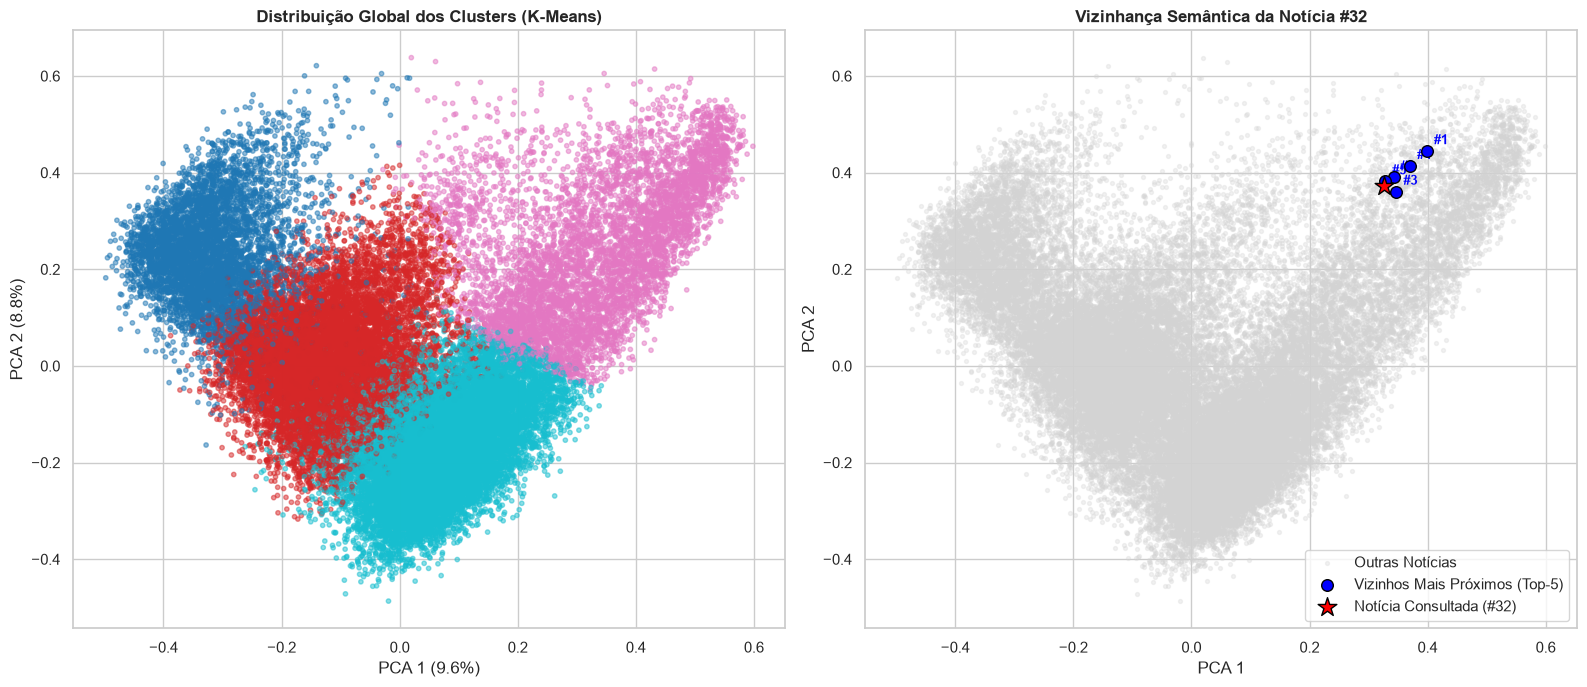

In [80]:
# Redução 2D para visualização
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
coords_pca = pca_2d.fit_transform(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 1. Mapa Global dos Clusters
scatter = ax1.scatter(
    coords_pca[:, 0], coords_pca[:, 1],
    c=chosen_labels, cmap='tab10',
    s=10, alpha=0.5
)
ax1.set_title(f'Distribuição Global dos Clusters ({chosen_model_name})', fontsize=12, fontweight='bold')
ax1.set_xlabel(f'PCA 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PCA 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

# 2. Destaque da Notícia Consultada e seus Vizinhos Mais Próximos
ax2.scatter(coords_pca[:, 0], coords_pca[:, 1], c='lightgray', s=8, alpha=0.3, label='Outras Notícias')

if top_indices is not None:
    ax2.scatter(
        coords_pca[top_indices, 0], coords_pca[top_indices, 1],
        color='blue', s=70, marker='o', edgecolors='black',
        label=f'Vizinhos Mais Próximos (Top-{len(top_indices)})', zorder=4
    )
    for rank, idx in enumerate(top_indices, start=1):
        ax2.annotate(f"#{rank}", (coords_pca[idx, 0], coords_pca[idx, 1]),
                     fontsize=9, fontweight='bold', color='blue', xytext=(5, 5), textcoords='offset points')

ax2.scatter(
    coords_pca[QUERY_INDEX, 0], coords_pca[QUERY_INDEX, 1],
    color='red', s=200, marker='*', edgecolors='black',
    label=f'Notícia Consultada (#{QUERY_INDEX})', zorder=5
)

ax2.set_title(f'Vizinhança Semântica da Notícia #{QUERY_INDEX}', fontsize=12, fontweight='bold')
ax2.set_xlabel('PCA 1')
ax2.set_ylabel('PCA 2')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()


### 14. Detecção de Anomalias e Notícias com Conteúdo Fora do Padrão
___
**O que esta célula faz:**
Aplica **Isolation Forest** e **Local Outlier Factor (LOF)** para identificar notícias semântica ou estruturalmente isoladas (textos fora do padrão, formatos raros ou notícias marginais com vocabulário atípico).


In [81]:
# 1. Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=RANDOM_STATE)
outliers_iso = iso_forest.fit_predict(X_pca)
n_outliers = np.sum(outliers_iso == -1)
print(f"Isolation Forest: {n_outliers} notícias atípicas identificadas ({n_outliers/len(X)*100:.2f}%)")

# Exibe 2 exemplos de notícias detectadas como anomalias
outlier_indices = np.where(outliers_iso == -1)[0]
print("\nExemplos de Notícias Atípicas (Anomalias semânticas identificadas):")
for i, out_idx in enumerate(outlier_indices[:2], start=1):
    txt_sample = news_texts[out_idx] if out_idx < len(news_texts) else "N/A"
    clean_sample = " ".join(txt_sample.strip().split())
    print(f"[{i}] Notícia #{out_idx}:")
    print(f"    \"{clean_sample[:200]}...\"\n")


Isolation Forest: 1177 notícias atípicas identificadas (3.00%)

Exemplos de Notícias Atípicas (Anomalias semânticas identificadas):
[1] Notícia #25:
    "“URGENTE! NOVO PROTOCOLO IVERMECTINA MARINHA DO BRASIL P/ A COVID-19, URGENT! NEW IVERMECTIN PROTOCOL”..."

[2] Notícia #72:
    "A CBF divulgou nesta sexta-feira algumas mudanças na tabela do Campeonato Brasileiro, a maior parte por adequação aos jogos da Libertadores e da Copa Sul-Americana. A partida entre Athletico-PR e São ..."



### 15. Tabela Comparativa Consolidada, Gráficos e Exportação
___
**O que esta célula faz:**
1. Consolida as métricas intrínsecas de todos os modelos avaliados em um DataFrame formatado.
2. Plota gráficos de barras comparativos (Silhouette e Davies-Bouldin).
3. Exporta as métricas para arquivo `.csv` e salva os rótulos de agrupamento e vizinhança em um arquivo `.npz` para consumo externo.


=== CONSOLIDAÇÃO DOS MODELOS NÃO SUPERVISIONADOS ===
                 Model  N_Clusters  Noise_Ratio_%  Silhouette  Davies_Bouldin  Calinski_Harabasz  Fit_Time_Sec
               HDBSCAN           4           0.02      0.0963          1.5753             483.32         3.691
                DBSCAN           6           2.58      0.0948          1.4917             293.84         1.798
     MiniBatch K-Means           4           0.00      0.0856          2.9856            2791.90         0.993
               K-Means           4           0.00      0.0850          2.9831            2794.14         6.315
  Agglomerative (Ward)           4           0.00      0.0738          3.1867            2515.03         0.964
Gaussian Mixture (GMM)           4           0.00      0.0436          3.0230            1688.58         0.989
                 BIRCH           4           0.00      0.0356          4.0598            1820.60         5.127


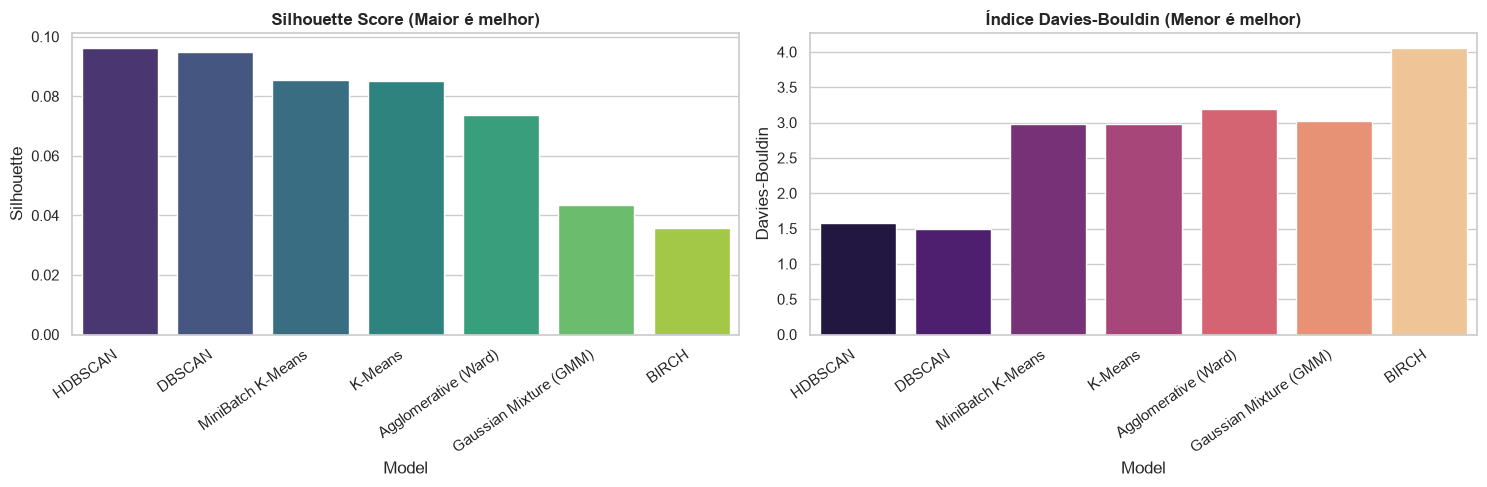

Relatório exportado em: 'results_unsupervised\unsupervised_metrics_20260921_155143.csv'
Rótulos dos clusters salvos em: 'results_unsupervised\unsupervised_clusters.npz'!


In [82]:
df_results = pd.DataFrame(unsupervised_results)
df_results = df_results.sort_values(by='Silhouette', ascending=False, na_position='last').reset_index(drop=True)

print("=== CONSOLIDAÇÃO DOS MODELOS NÃO SUPERVISIONADOS ===")
display_cols = [c for c in ['Model', 'N_Clusters', 'Noise_Ratio_%', 'Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz', 'Fit_Time_Sec'] if c in df_results.columns]
print(df_results[display_cols].to_string(index=False))

# Gráfico Comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Silhouette (Maior é melhor)
sns.barplot(data=df_results.dropna(subset=['Silhouette']), x='Model', y='Silhouette', palette='viridis', ax=ax1)
ax1.set_title('Silhouette Score (Maior é melhor)', fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=35, ha='right')
ax1.set_ylabel('Silhouette')

# Davies-Bouldin (Menor é melhor)
sns.barplot(data=df_results.dropna(subset=['Davies_Bouldin']), x='Model', y='Davies_Bouldin', palette='magma', ax=ax2)
ax2.set_title('Índice Davies-Bouldin (Menor é melhor)', fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right')
ax2.set_ylabel('Davies-Bouldin')

plt.tight_layout()
plt.show()

# Exportação do relatório CSV com timestamp
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = os.path.join(OUTPUT_DIR, f"unsupervised_metrics_{ts}.csv")
df_results.to_csv(csv_path, index=False)
print(f"Relatório exportado em: '{csv_path}'")

# Exportação dos clusters atribuídos
export_npz_path = os.path.join(OUTPUT_DIR, "unsupervised_clusters.npz")
export_data = {f"cluster_{name.replace(' ', '_').lower()}": lbls for name, lbls in predicted_cluster_labels.items()}
np.savez_compressed(export_npz_path, **export_data)
print(f"Rótulos dos clusters salvos em: '{export_npz_path}'!")


=== DISTRIBUIÇÃO DE VERACIDADE POR CLUSTER ===
Contagens absolutas:


col_0,Falsa,Verdadeira
row_0,,
0,81,5332
1,4176,7506
2,4502,1530
3,14445,1647


Percentuais dentro de cada cluster:


col_0,Falsa,Verdadeira
row_0,,
0,1.50,98.50
1,35.75,64.25
2,74.64,25.36
3,89.77,10.23


Resumo exportado em: 'results_unsupervised\truth_distribution_by_cluster.csv'


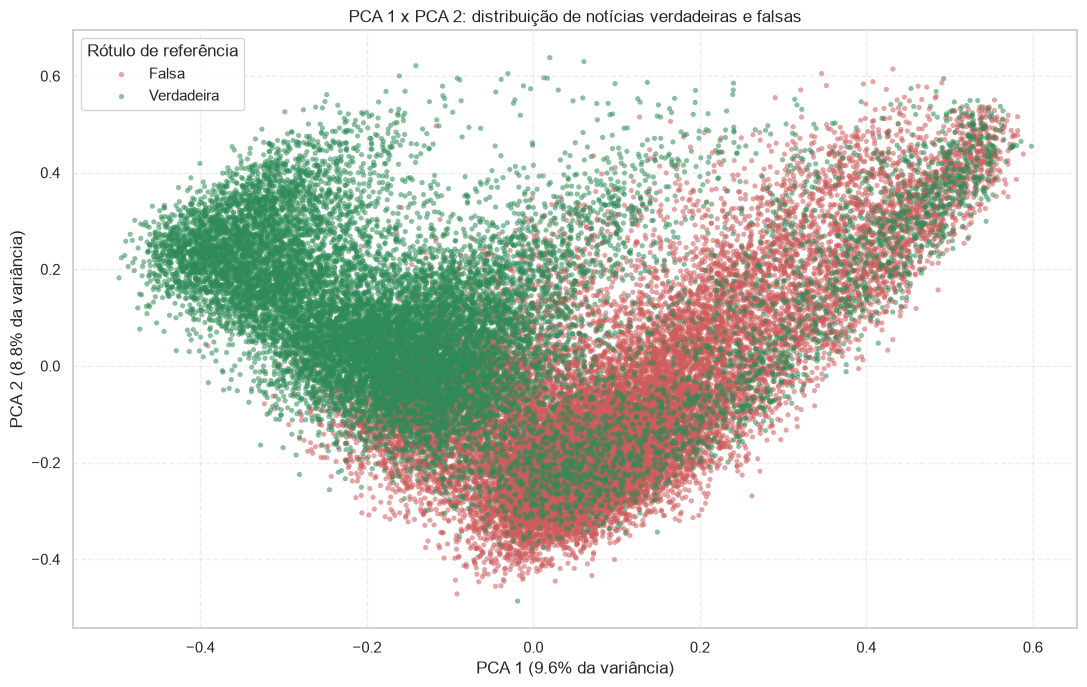

In [84]:
# Distribuição de veracidade por cluster e projeção PCA 1 x PCA 2
if y_true is None:
    print("Os rótulos de referência (y_true) não estão disponíveis no arquivo de embeddings.")
else:
    labels_ref = np.asarray(y_true).reshape(-1)
    labels_cluster = np.asarray(chosen_labels).reshape(-1)
    n_aligned = min(len(labels_ref), len(labels_cluster), len(coords_pca))

    def normalizar_rotulo_veracidade(label):
        valor = str(label).strip().lower()
        if valor in {'1', 'true', 'verdadeiro', 'verdadeira', 'real', 'real news'}:
            return 'Verdadeira'
        if valor in {'0', 'false', 'falso', 'falsa', 'fake', 'fake news'}:
            return 'Falsa'
        return str(label)

    truth_labels = np.array([
        normalizar_rotulo_veracidade(label)
        for label in labels_ref[:n_aligned]
    ])
    cluster_labels_aligned = labels_cluster[:n_aligned]

    distribution_counts = pd.crosstab(
        cluster_labels_aligned,
        truth_labels
    ).sort_index()
    distribution_percent = distribution_counts.div(
        distribution_counts.sum(axis=1), axis=0
    ).mul(100).round(2)

    print('=== DISTRIBUIÇÃO DE VERACIDADE POR CLUSTER ===')
    print('Contagens absolutas:')
    display(distribution_counts)
    print('Percentuais dentro de cada cluster:')
    display(distribution_percent)

    df_cluster_truth_summary = distribution_counts.copy()
    for column in distribution_percent.columns:
        df_cluster_truth_summary[f'{column}_%'] = distribution_percent[column]

    truth_summary_path = os.path.join(OUTPUT_DIR, 'truth_distribution_by_cluster.csv')
    df_cluster_truth_summary.to_csv(truth_summary_path, index=True)
    print(f"Resumo exportado em: '{truth_summary_path}'")

    # Scatterplot PCA 1 x PCA 2 colorido pelo rótulo de veracidade.
    truth_colors = {'Verdadeira': 'seagreen', 'Falsa': 'indianred'}
    fig, ax = plt.subplots(figsize=(11, 7))
    for truth_value in pd.unique(truth_labels):
        mask = truth_labels == truth_value
        ax.scatter(
            coords_pca[:n_aligned, 0][mask],
            coords_pca[:n_aligned, 1][mask],
            s=14,
            alpha=0.55,
            c=truth_colors.get(truth_value, 'steelblue'),
            label=truth_value,
            edgecolors='none'
        )

    ax.set_title('PCA 1 x PCA 2: distribuição de notícias verdadeiras e falsas')
    ax.set_xlabel(f'PCA 1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% da variância)')
    ax.set_ylabel(f'PCA 2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% da variância)')
    ax.legend(title='Rótulo de referência')
    ax.grid(True, linestyle='--', alpha=0.35)
    plt.tight_layout()
    plt.show()

=== DISTRIBUIÇÃO DE VERACIDADE POR CLUSTER ===
Contagens absolutas:


Veracidade,Falsa,Verdadeira
Cluster,,
0,81,5332
1,4176,7506
2,4502,1530
3,14445,1647


Percentuais dentro de cada cluster:


Veracidade,Falsa,Verdadeira
Cluster,,
0,1.50,98.50
1,35.75,64.25
2,74.64,25.36
3,89.77,10.23


Veracidade,Falsa,Verdadeira,Falsa_%,Verdadeira_%
Cluster,,,,
0,81,5332,1.50,98.50
1,4176,7506,35.75,64.25
2,4502,1530,74.64,25.36
3,14445,1647,89.77,10.23


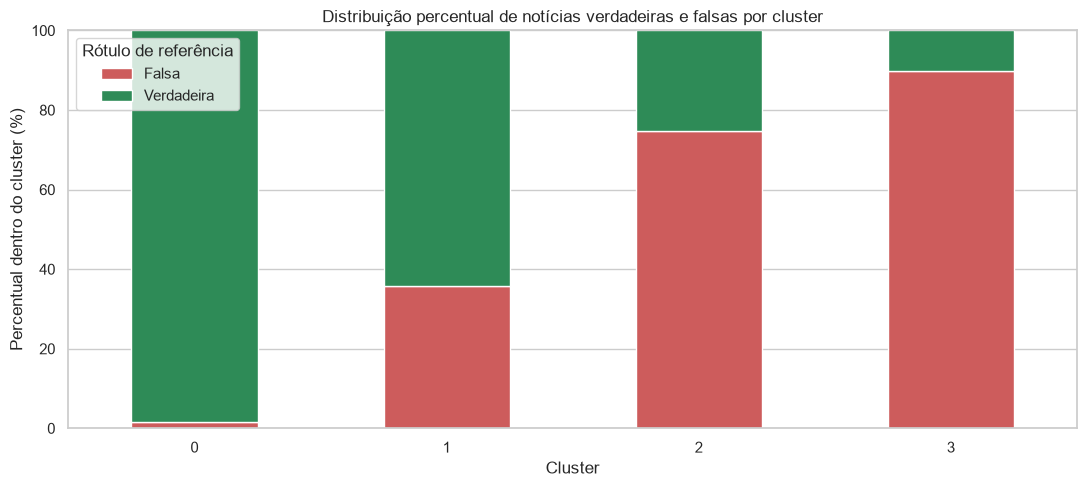

Resumo exportado em: 'results_unsupervised\truth_distribution_by_cluster.csv'


In [83]:
# Análise da distribuição de notícias verdadeiras e falsas por cluster
if y_true is None:
    print("Os rótulos de referência (y_true) não estão disponíveis no arquivo de embeddings.")
else:
    labels_ref = np.asarray(y_true).reshape(-1)
    labels_cluster = np.asarray(chosen_labels).reshape(-1)
    n_aligned = min(len(labels_ref), len(labels_cluster))

    if len(labels_ref) != len(labels_cluster):
        print(
            f"Aviso: tamanhos diferentes entre y_true ({len(labels_ref)}) e clusters "
            f"({len(labels_cluster)}). Usando os primeiros {n_aligned} registros alinhados."
        )

    def normalizar_rotulo_veracidade(label):
        valor = str(label).strip().lower()
        if valor in {'1', 'true', 'verdadeiro', 'verdadeira', 'real', 'real news'}:
            return 'Verdadeira'
        if valor in {'0', 'false', 'falso', 'falsa', 'fake', 'fake news'}:
            return 'Falsa'
        return str(label)

    df_cluster_truth = pd.DataFrame({
        'Cluster': labels_cluster[:n_aligned],
        'Veracidade': [normalizar_rotulo_veracidade(label) for label in labels_ref[:n_aligned]]
    })

    # Contagens absolutas e percentuais dentro de cada cluster.
    distribution_counts = pd.crosstab(
        df_cluster_truth['Cluster'],
        df_cluster_truth['Veracidade']
    ).sort_index()
    distribution_percent = distribution_counts.div(
        distribution_counts.sum(axis=1), axis=0
    ).mul(100).round(2)

    print('=== DISTRIBUIÇÃO DE VERACIDADE POR CLUSTER ===')
    print('Contagens absolutas:')
    display(distribution_counts)
    print('Percentuais dentro de cada cluster:')
    display(distribution_percent)

    # Tabela consolidada para facilitar exportação e comparação entre clusters.
    df_cluster_truth_summary = distribution_counts.copy()
    for column in distribution_percent.columns:
        df_cluster_truth_summary[f'{column}_%'] = distribution_percent[column]
    display(df_cluster_truth_summary)

    ax = distribution_percent.plot(
        kind='bar',
        stacked=True,
        figsize=(11, 5),
        color={'Verdadeira': 'seagreen', 'Falsa': 'indianred'}
    )
    ax.set_title('Distribuição percentual de notícias verdadeiras e falsas por cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Percentual dentro do cluster (%)')
    ax.set_ylim(0, 100)
    ax.legend(title='Rótulo de referência')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Exporta o resumo para consulta posterior junto dos demais resultados.
    truth_summary_path = os.path.join(OUTPUT_DIR, 'truth_distribution_by_cluster.csv')
    df_cluster_truth_summary.to_csv(truth_summary_path, index=True)
    print(f"Resumo exportado em: '{truth_summary_path}'")